# House Prices Prediction using Machine Learning

## Regression Analysis and Model Comparison

This project predicts house sale prices using machine learning algorithms. Multiple regression models are trained and evaluated to identify the best-performing model.

In [191]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [192]:
df = pd.read_csv("train.csv")

In [193]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [194]:
df.shape

(1460, 81)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [196]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


# **Data Preprocessing**

In [197]:
df.drop(columns=["PoolQC"], inplace=True)
df.drop(columns=["MiscFeature"], inplace=True)
df.drop(columns=["Alley"], inplace=True)
df.drop(columns=["Fence"], inplace=True)
df.drop(columns=["MasVnrType"], inplace=True)

In [198]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["FireplaceQu"] = df["FireplaceQu"].fillna("Unknown")

In [199]:
basement_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

for col in basement_cols:
    df[col] = df[col].fillna("No Basement")

garage_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for col in garage_cols:
    df[col] = df[col].fillna("No Garage")

In [200]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna("Unknown")
df["Electrical"] = df["Electrical"].fillna("Unknown")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

# **Feature Engineering**

In [202]:
numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

In [203]:
corr = numeric_df.corr()

In [204]:
corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


# **Feature Selection**

In [205]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

In [206]:
X = df[features]
y = df["SalePrice"]

# **Train-Test Split**


In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was divided into 80% training data and 20% testing data to evaluate model performance on unseen samples.

# **Model 1 – Linear Regression**

In [208]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

## Model Evaluation

In [209]:
mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 25284.80968862931
RMSE: 39979.43012458342
R2 Score: 0.7916184018889857


# **Model 2 – Decision Tree Regression**

In [210]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

## Model Evaluation

In [211]:
mae = mean_absolute_error(y_test, pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, pred_dt))
r2 = r2_score(y_test, pred_dt)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 26125.124429223746
RMSE: 38628.62445057166
R2 Score: 0.8054619077940736


# **Model 3 – Random Forest Regression**

In [212]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

## Model Evaluation

In [213]:
mae = mean_absolute_error(y_test, pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
r2 = r2_score(y_test, pred_rf)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 20133.95993421153
RMSE: 30642.788052640346
R2 Score: 0.8775827214807097


# **Comparison Table**

In [214]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE":[
        lr_results[0],
        dt_results[0],
        rf_results[0]
    ],
    "RMSE":[
        lr_results[1],
        dt_results[1],
        rf_results[1]
    ],
    "R2 Score":[
        lr_results[2],
        dt_results[2],
        rf_results[2]
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,25284.809689,39979.430125,0.791618
1,Decision Tree,26125.124429,38628.624451,0.805462
2,Random Forest,20133.959934,30642.788053,0.877583


# **Residual Plot**

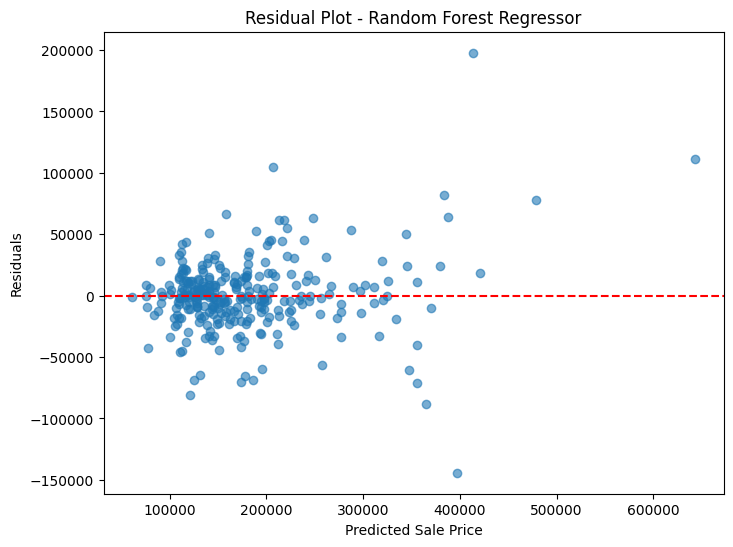

In [215]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,6))

plt.scatter(pred_rf, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")

plt.show()

## Best Model Analysis

Among the three models tested, Random Forest Regressor achieved the best performance based on RMSE and R² Score.

Reasons:
1. It captures complex non-linear relationships.
2. It reduces overfitting through ensemble learning.
3. It provides more stable predictions than a single decision tree.

## Conclusion

Three machine learning models were trained and compared for predicting house sale prices. Random Forest Regressor achieved the best performance and was selected as the final model. Feature analysis showed that overall house quality, living area, garage capacity, and basement area significantly influence house prices. The project demonstrates the complete machine learning workflow from preprocessing to evaluation.